#Introduction

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Data Loading

In [73]:
df = pd.read_csv("online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


##Data Understanding

In [74]:
df.shape

(247210, 8)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247210 entries, 0 to 247209
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      247210 non-null  object 
 1   StockCode    247210 non-null  object 
 2   Description  246279 non-null  object 
 3   Quantity     247210 non-null  int64  
 4   InvoiceDate  247210 non-null  object 
 5   Price        247210 non-null  float64
 6   Customer ID  178045 non-null  float64
 7   Country      247210 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 15.1+ MB


In [76]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,931
Quantity,0
InvoiceDate,0
Price,0
Customer ID,69165
Country,0


In [77]:
df.describe()

,Quantity,Price,Customer ID
count,247210.000000,247210.000000,178045.000000
mean,9.307949,5.085422,15284.507276
std,219.907954,118.266371,1725.463220
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13856.000000
50%,3.000000,2.100000,15150.000000
75%,10.000000,4.210000,16818.000000
max,74215.000000,38970.000000,18287.000000


In [78]:
df.duplicated().sum()

np.int64(2040)

In [79]:
df = df.drop_duplicates()

In [80]:
df.duplicated().sum()

np.int64(0)

##Data Cleaning

In [81]:
df["Description"] = df["Description"].fillna("Unknown Product")

In [82]:
df = df.drop(columns=["Customer ID"], errors='ignore')

In [83]:
df = df[df["Quantity"] > 0]

In [84]:
df = df[df["Price"] > 0]

In [85]:
df.shape

(239169, 7)

In [86]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

In [87]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [88]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

In [89]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,Revenue,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,2010,12,1,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
247205,558759,21890,S/6 WOODEN SKITTLES IN COTTON BAG,3,2011-07-03 12:36:00,3.25,United Kingdom,9.75,2011,7,3,Sunday
247206,558759,21828,EIGHT PIECE SNAKE SET,2,2011-07-03 12:36:00,1.25,United Kingdom,2.50,2011,7,3,Sunday
247207,558759,21829,DINOSAUR KEYRINGS ASSORTED,36,2011-07-03 12:36:00,0.21,United Kingdom,7.56,2011,7,3,Sunday
247208,558759,22271,FELTCRAFT DOLL ROSIE,2,2011-07-03 12:36:00,2.95,United Kingdom,5.90,2011,7,3,Sunday


## Exploratory Data Analysis (EDA)

In [90]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

##Monthly Revenue Trend

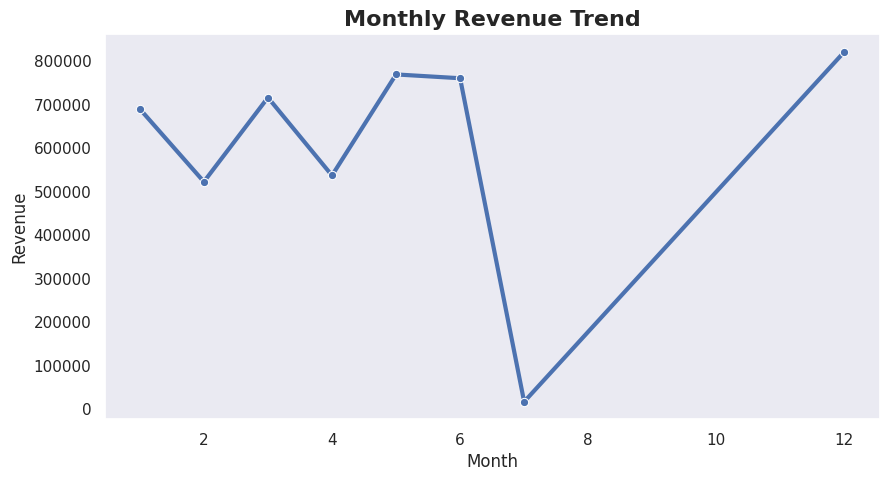

In [129]:
monthly_revenue = df.groupby(["Year","Month"])["Revenue"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

##Top 10 Products by Revenue

/tmp/ipykernel_231/2917948406.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


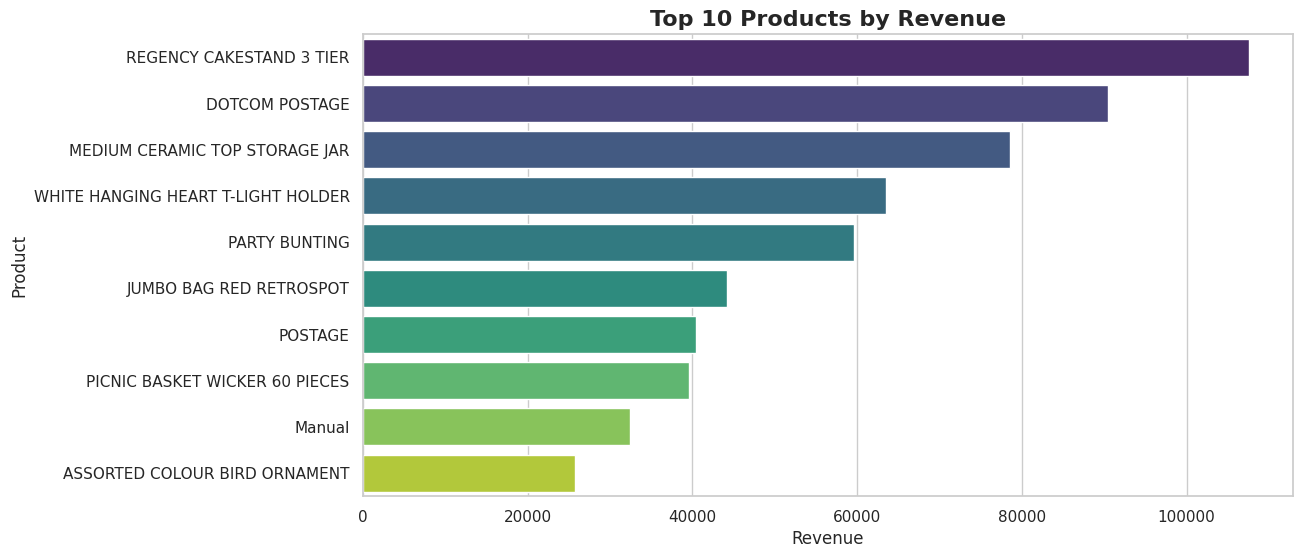

In [92]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Products by Revenue", fontsize=16, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

##Top Countries by Revenue

/tmp/ipykernel_231/915591011.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


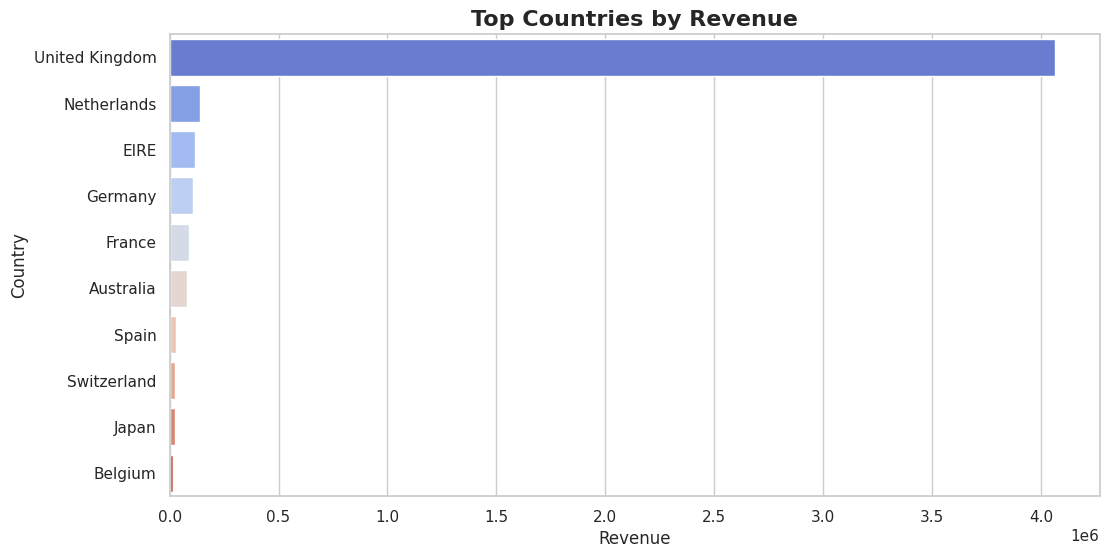

In [93]:
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette="coolwarm"
)

plt.title("Top Countries by Revenue", fontsize=16, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

##Day of Week Sales Pattern

/tmp/ipykernel_231/1007668464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


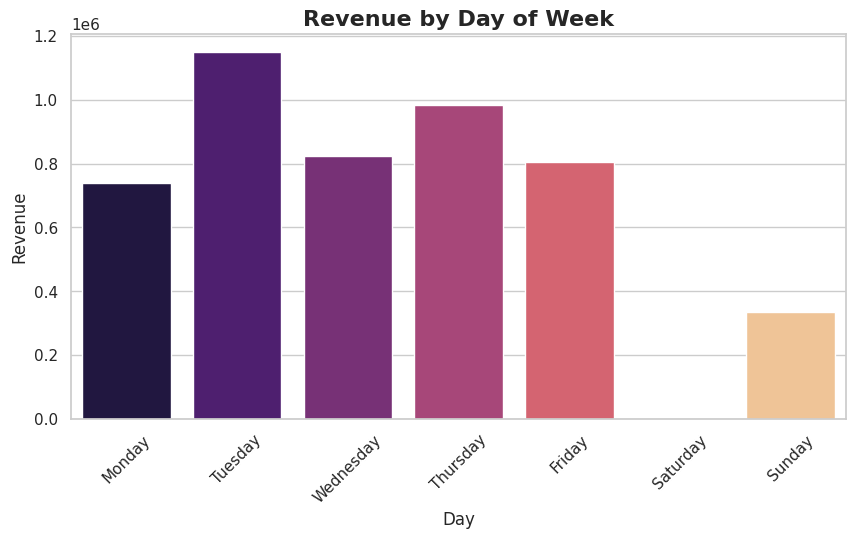

In [94]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_sales = df.groupby("DayOfWeek")["Revenue"].sum().reindex(order).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_sales,
    x="DayOfWeek",
    y="Revenue",
    palette="magma"
)

plt.title("Revenue by Day of Week", fontsize=16, weight="bold")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

##Quantity vs Revenue Relationship

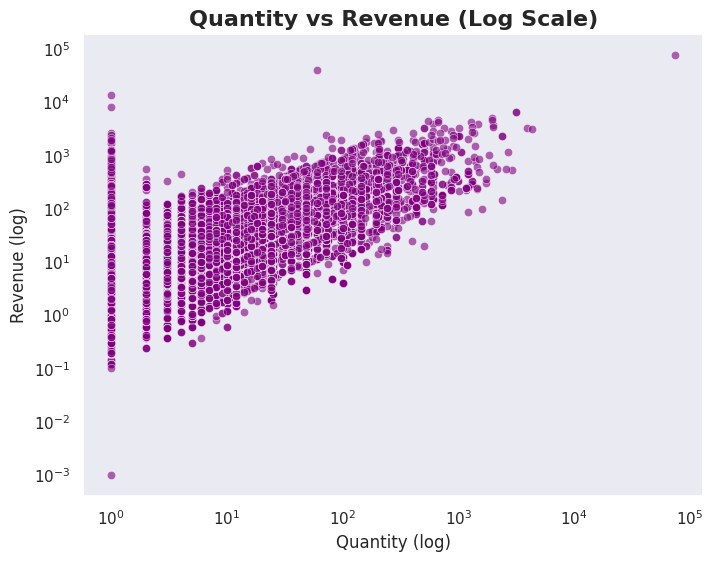

In [131]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
    color="purple",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Quantity vs Revenue (Log Scale)", fontsize=16, weight="bold")
plt.xlabel("Quantity (log)")
plt.ylabel("Revenue (log)")

plt.show()

##Correlation Heatmap

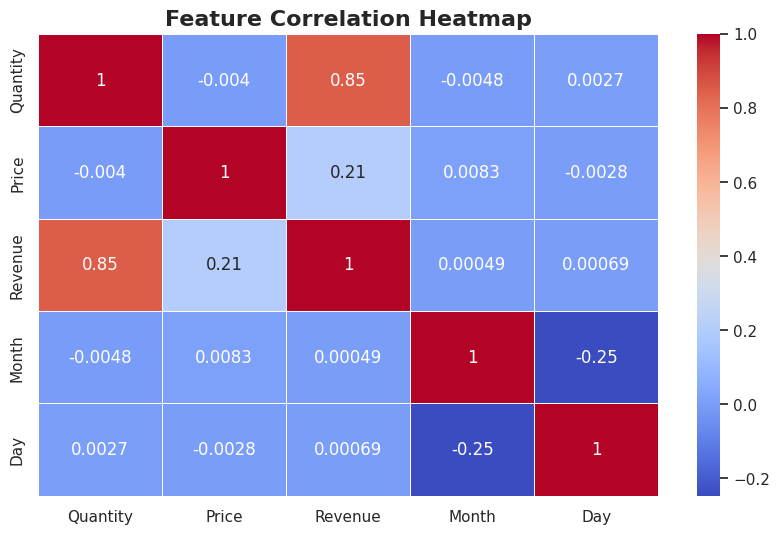

In [96]:
plt.figure(figsize=(10,6))

corr = df[["Quantity","Price","Revenue","Month","Day"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16, weight="bold")

plt.show()

##Sales Seasonality Heatmap (Month vs Year)

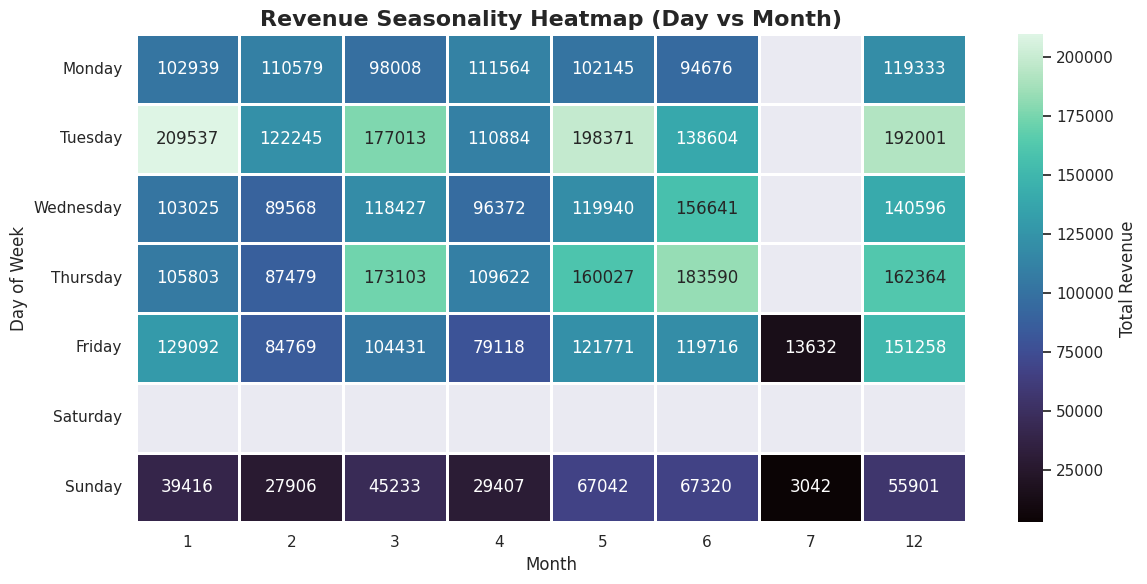

In [97]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

seasonality = df.pivot_table(
    values="Revenue",
    index="DayOfWeek",
    columns="Month",
    aggfunc="sum"
).reindex(order)

plt.figure(figsize=(12,6))

sns.set_theme(style="dark")   # Dark background theme

sns.heatmap(
    seasonality,
    cmap="mako",              # Completely different color palette
    annot=True,
    fmt=".0f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Total Revenue"}
)

plt.title("Revenue Seasonality Heatmap (Day vs Month)", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [98]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'DayOfWeek'],
      dtype='object')

##Daily Sales Time Series

In [99]:
daily_sales = df.resample("D", on="InvoiceDate")["Revenue"].sum().reset_index()

daily_sales.head()

,InvoiceDate,Revenue
0,2010-12-01,58776.79
1,2010-12-02,47629.42
2,2010-12-03,46898.63
3,2010-12-04,0.00
4,2010-12-05,31364.63


In [100]:
daily_sales.set_index("InvoiceDate", inplace=True)

daily_sales.head()

,Revenue
InvoiceDate,
2010-12-01,58776.79
2010-12-02,47629.42
2010-12-03,46898.63
2010-12-04,0.00
2010-12-05,31364.63


In [101]:
daily_sales = daily_sales.asfreq("D")

daily_sales["Revenue"] = daily_sales["Revenue"].fillna(0)

##Feature Engineering

In [102]:
data = daily_sales.copy()

data["day"] = data.index.day

data["month"] = data.index.month

data["day_of_week"] = data.index.dayofweek

In [103]:
data["lag_1"] = data["Revenue"].shift(1)

data["lag_7"] = data["Revenue"].shift(7)

In [104]:
data["rolling_mean_7"] = data["Revenue"].shift(1).rolling(window=7).mean()

In [105]:
data = data.dropna()

data.head()

,Revenue,day,month,day_of_week,lag_1,lag_7,rolling_mean_7
InvoiceDate,,,,,,,
2010-12-08,45235.36,8,12,2,99553.85,58776.79,48406.781429
2010-12-09,53548.19,9,12,3,45235.36,47629.42,46472.291429
2010-12-10,59021.02,10,12,4,53548.19,46898.63,47317.830000
2010-12-11,0.00,11,12,5,59021.02,0.00,49049.600000
2010-12-12,17125.65,12,12,6,0.00,31364.63,49049.600000


In [106]:
X = data.drop("Revenue", axis=1)

y = data["Revenue"]

##Train Test Split

In [107]:
train_size = int(len(data) * 0.8)

X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]

##Linear Regression

In [108]:
from sklearn.linear_model import LinearRegression

In [109]:
lr_model = LinearRegression()

In [110]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [111]:
lr_pred = lr_model.predict(X_test)

###Linear Regression Metrics

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [113]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")

print("MAE:", lr_mae)

print("RMSE:", lr_rmse)

print("R2 Score:", lr_r2)

Linear Regression
MAE: 9456.597408500613
RMSE: 12641.741248310695
R2 Score: 0.34146358108707753


##Random Forest

In [114]:
from sklearn.ensemble import RandomForestRegressor

In [115]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [116]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [117]:
rf_pred = rf_model.predict(X_test)

###Random Forest Metrics

In [132]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("R2 Score:", rf_r2)


Random Forest
MAE: 8403.051168095235
RMSE: 11269.67863910898
R2 Score: 0.47665380859519235


##xgboost

In [119]:
from xgboost import XGBRegressor

In [133]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [134]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [135]:
xgb_pred = xgb_model.predict(X_test)

###XGBoost Metrics

In [123]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

print("\nXGBoost")

print("MAE:", xgb_mae)

print("RMSE:", xgb_rmse)

print("R2 Score:", xgb_r2)


XGBoost
MAE: 8552.620237281435
RMSE: 10992.722893899536
R2 Score: 0.5020605164656616


##Model Evaluation

In [124]:
results = pd.DataFrame({

    "Model": ["Linear Regression", "Random Forest", "XGBoost"],

    "MAE": [lr_mae, rf_mae, xgb_mae],

    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],

    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9456.597409,12641.741248,0.341464
1,Random Forest,8403.051168,11269.678639,0.476654
2,XGBoost,8552.620237,10992.722894,0.502061


##Prediction Graph

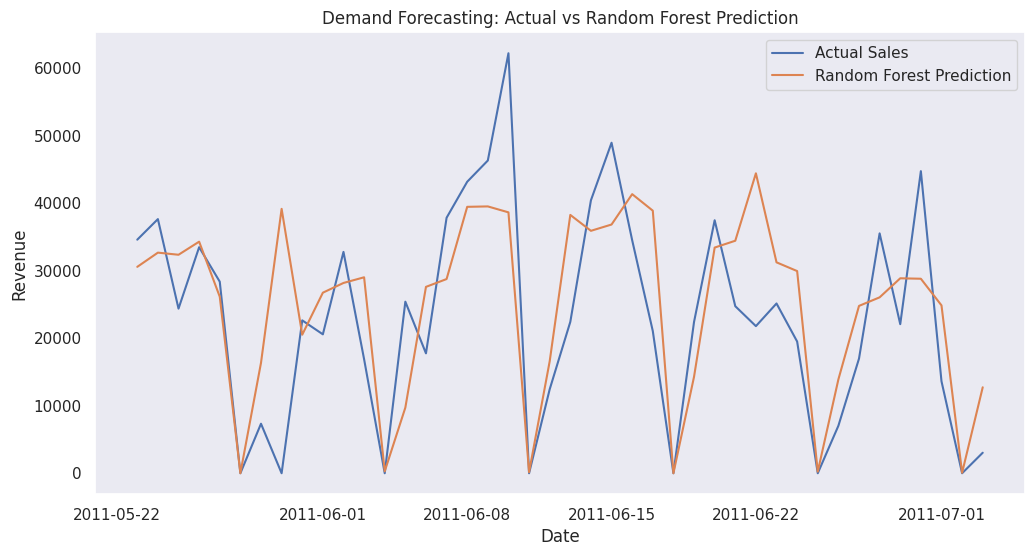

In [137]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Sales")

plt.plot(y_test.index, rf_pred, label="Random Forest Prediction")

plt.legend()

plt.title("Demand Forecasting: Actual vs Random Forest Prediction")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()